# Weak non-Gaussian factor simulation

This notebook mirrors the motivation of the upstream HOFA simulation: compare covariance PCA with higher-order factor analysis when the latent factors are non-Gaussian and relatively weak.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import pyhofa


In [2]:
sim = pyhofa.dgp2(
    n=80,
    t=300,
    k=2,
    factor_lambda=[0.8, 0.8],
    factor_p=[1.0, 1.0],
    factor_q=[np.inf, np.inf],
    factor_ar=[0.5, 0.2],
    error_lambda=0.0,
    error_p=2.0,
    error_q=np.inf,
    beta=0.15,
    neighborhood=5,
    error_ar=0.15,
    error_variance_range=(1.0, 2.0),
    loading_strength=[0.35, 0.25],
    random_state=123,
)
X = sim.X


In [3]:
selectors = {
    "ER": pyhofa.m2_select(X, method="ER", rmax=6).R,
    "GER3": pyhofa.m3_select(X, method="GER3", rmax=6).Rh,
    "GER4": pyhofa.m4_select(X, method="GER4", rmax=6).Rh,
}
selectors


{'ER': 1, 'GER3': 2, 'GER4': 1}

In [4]:
pca = pyhofa.m2_pca(X, r=2)
hfa3 = pyhofa.m3_als(X, rh=2, rg=0)
hfa4 = pyhofa.m4_als(X, rh=2, rg=0)

scores = pd.Series({
    "PCA": pyhofa.trace_ratio(pca.factors, sim.factors),
    "HFA-3": pyhofa.trace_ratio(hfa3.factors, sim.factors),
    "HFA-4": pyhofa.trace_ratio(hfa4.factors, sim.factors),
}, name="factor trace ratio")
scores


PCA      0.180924
HFA-3    0.528015
HFA-4    0.477541
Name: factor trace ratio, dtype: float64

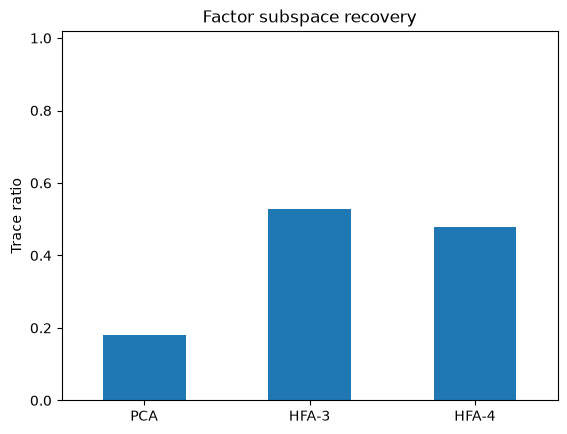

In [5]:
ax = scores.plot.bar(rot=0, title="Factor subspace recovery")
ax.set_ylim(0, 1.02)
ax.set_ylabel("Trace ratio")
plt.show()


The simulation is stochastic, so the exact ranking can change with the seed and signal strength. The useful diagnostic is whether higher-order information improves recovery as the covariance signal weakens.
